In [33]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv
import src.onekg as og

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Main Figures

### Figure 1.

1. **Summary of project design and descriptive statistics of datasets**
    1. Biobank cohorts
        1. Datasets
            1. 1000_Genomes_on_GRCh38
            2. Human_Genome_Diversity_Project
            3. All of Us [*tentative*]
            4. TOPMed [*tentative*]
            5. TCGA [*tentative*]
        2. Number of substitutions/indels in WT sequences
        3. Number of haplotypes per transcript
        4. Number of [super]populations each haplotype appears in (>0% freq)
    2. Clinical variants
        1. Datasets
            1. ClinVar
                1. Molecular Consequences
                    1. Missense, UTR, Splicing, etc.
                <!-- 2. Clinical Significance
                    1. Pathogenic, Benign, VUS -->
    3. Models
        1. Protein
            1. ESM 1/1b/1v/2
            2. ESMfold [*tentative*]
            3. ESM3/C
            4. AlphaFold
            5. AlphaMissense [*tentative*]
            6. EVE [*tentative*]
        2. DNA
            1. Borzoi
            2. Saluki [*tentative*]
            3. SpliceAI [*tentative]*
            4. Evo 2
    4. Methods
        1. Cartoon illustration of how we construct personalized sequences
        2. Cartoon illustration of 1 VEP per variant vs. VEP distributions

#### Fig 1: Population variant summaries

In [86]:
onekg_meta = og.get_sample_metadata()
superpop_counts = onekg_meta.groupby("Super Population").size().reset_index().rename(columns={0: "Individuals"})
superpop_counts

,Super Population,Individuals
0,AFR,1044
1,AMR,535
2,EAS,673
3,EUR,670
4,SAS,661


In [72]:
vcf_summary = og.get_onekg_vcf_summary()
vcf_summary.head()

,Accessibility,Consequence Type,Freq BIN,Sup Pop,Median Der Allele Count,Median Het Count,Median Hom Count,Median Site Count
0,Accessible,3_prime_UTR_variant,>5%,SAS,19984.0,12935.0,3538.0,16465.0
1,Accessible,3_prime_UTR_variant,>5%,EUR,19707.0,12671.0,3511.0,16191.0
2,Accessible,3_prime_UTR_variant,>5%,EAS,19904.0,11807.5,4046.5,15855.0
3,Accessible,3_prime_UTR_variant,>5%,AMR,19883.0,13020.0,3422.0,16483.0
4,Accessible,3_prime_UTR_variant,>5%,AFR,19397.0,13500.0,2941.0,16442.0


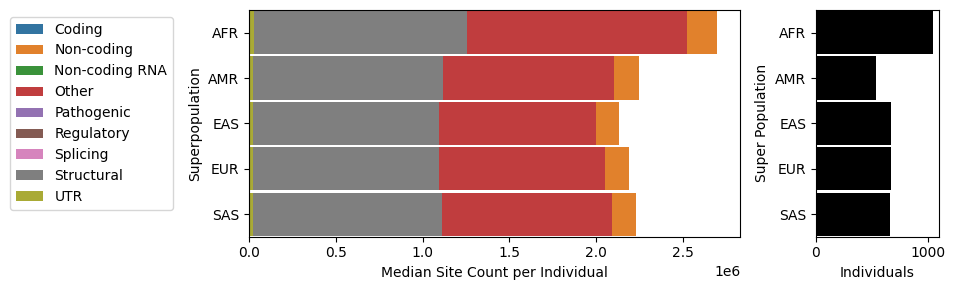

In [83]:
# Mapping of complex annotations to simplified categories
cs_simple = {
    # UTR variants
    '3_prime_UTR_variant': 'UTR',
    '5_prime_UTR_variant': 'UTR',
    
    # Clinical significance
    'CLINVAR_clnsig=4': 'Pathogenic',
    'CLINVAR_clnsig=5': 'Pathogenic',
    'HGMD-DM': 'Pathogenic',
    
    # Regulatory elements
    'ctcf_insulator': 'Regulatory',
    'distal_enhancer': 'Regulatory',
    'proximal_enhancer': 'Regulatory',
    'promoter': 'Regulatory',
    'regulatory_region_variant': 'Regulatory',
    'TF_binding_site_variant': 'Regulatory',
    'unannotated_tfbs': 'Regulatory',
    
    # Coding variants
    'frameshift_variant': 'Coding',
    'frameshift_variant_aloft': 'Coding',
    'inframe': 'Coding',
    'missense_variant': 'Coding',
    'stop_gained': 'Coding',
    'stop_gained_aloft': 'Coding',
    'stop_lost': 'Coding',
    'synonymous_variant': 'Coding',
    
    # Splicing variants
    'splice_acceptor_variant': 'Splicing',
    'splice_acceptor_variant_aloft': 'Splicing',
    'splice_donor_variant': 'Splicing',
    'splice_donor_variant_aloft': 'Splicing',
    
    # Non-coding RNA
    'mature_miRNA_variant': 'Non-coding RNA',
    
    # Intergenic and intronic
    'intergenic_variant': 'Non-coding',
    'intron_variant': 'Non-coding',
    
    # Structural variants
    'Large_Deletion_NON_OVERLAP_GENE': 'Structural',
    'Large_Deletion_OVERLAP_GENE': 'Structural',
    'small_indel_all_NON_OVERLAP_GENE': 'Structural',
    'small_indel_all_OVERLAP_GENE': 'Structural',
    'small_indel_filtered_NON_OVERLAP_GENE': 'Structural',
    'small_indel_filtered_OVERLAP_GENE': 'Structural',
    
    # Other annotations
    'FunSeq_score>1.5': 'Other',
    'GWAS_3465': 'Other',
    'PHOSPHORYLATION_evidence<=5': 'Other',
    'PHOSPHORYLATION_evidence>5': 'Other',
    'total_site': 'Other'
}

vcf_summary["consequence_type_simple"] = vcf_summary["Consequence Type"].map(cs_simple)
vcf_summary["consequence_type_simple"].unique()

count_col = "Median Site Count"
vcf_summar_count = vcf_summary.groupby(["consequence_type_simple", "Sup Pop"])[count_col].sum().reset_index()

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), width_ratios=[1, 0.25])

# First subplot - consequence types
sns.barplot(data=vcf_summar_count,
            y="Sup Pop",
            x=count_col, 
            hue="consequence_type_simple", 
            dodge=False,
            width=0.95,
            ax=ax1)
ax1.legend(bbox_to_anchor=(-0.5, 1), loc='upper left')
ax1.set_xlabel(count_col+" per Individual")
ax1.set_ylabel("Superpopulation") 

# Second subplot - individual counts
sns.barplot(data=superpop_counts, 
            y="Super Population", 
            x="Individuals", 
            dodge=False,
            color="black",
            width=0.95,
            ax=ax2) 

plt.tight_layout()
plt.show()

#### Fig 1: Clinical variant summaries

In [125]:
# ClinVar: UTR
utr_variants = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz").to_pandas()

utr_counts = utr_variants.groupby("CLNSIG_super_simple").size().reset_index().rename(columns={"CLNSIG_super_simple":"ClinSig", 0: "Count"})
utr_counts["ClinSig"] = utr_counts["ClinSig"].str.replace("path","pathogenic")
utr_counts["Source"] = "ClinVar"
utr_counts["Consequence"] = "UTR"
utr_counts

,ClinSig,Count,Source,Consequence
0,benign,11718,ClinVar,UTR
1,pathogenic,2053,ClinVar,UTR


In [126]:
# SpliceVarDB: splicing
splice_variants = pd.read_csv("data/splicing/splicevardb_x_clinvar_snv.csv")

splice_counts = splice_variants.groupby("CLNSIG_simplified").size().reset_index().rename(columns={"CLNSIG_simplified":"ClinSig", 0: "Count"})
splice_counts["Source"] = "SpliceVarDB"
splice_counts["Consequence"] = "Splicing"
splice_counts


,ClinSig,Count,Source,Consequence
0,benign,2615,SpliceVarDB,Splicing
1,pathogenic,3327,SpliceVarDB,Splicing
2,vus,2548,SpliceVarDB,Splicing


In [127]:
# ProteinGym: missense
pg_subs_paths = pooch.retrieve("https://marks.hms.harvard.edu/proteingym/ProteinGym_v1.3/clinical_ProteinGym_substitutions.zip",
                known_hash=None,
                processor=pooch.Unzip(),
                progressbar=True)

pg_subs = pd.concat([pd.read_csv(path, index_col=0) for path in tqdm(pg_subs_paths)])

sub_counts = pg_subs.groupby("DMS_bin_score").size().reset_index().rename(columns={"DMS_bin_score":"ClinSig", 0: "Count"})
sub_counts["Source"] = "ProteinGym"
sub_counts["Consequence"] = "Missense"
sub_counts


100%|██████████| 2525/2525 [00:02<00:00, 1051.84it/s]


,ClinSig,Count,Source,Consequence
0,Benign,30727,ProteinGym,Missense
1,Pathogenic,32000,ProteinGym,Missense


      ClinSig  Count       Source Consequence    Consequence (Source)
0      Benign  11718      ClinVar         UTR           UTR (ClinVar)
1  Pathogenic   2053      ClinVar         UTR           UTR (ClinVar)
0      Benign   2615  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
1  Pathogenic   3327  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
0      Benign  30727   ProteinGym    Missense   Missense (ProteinGym)
1  Pathogenic  32000   ProteinGym    Missense   Missense (ProteinGym)


Text(0, 0.5, 'Consequence (Source)')

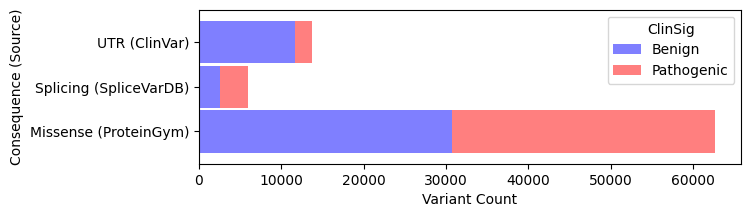

In [171]:
variant_counts = pd.concat([utr_counts, splice_counts, sub_counts])
variant_counts["ClinSig"] = variant_counts["ClinSig"].str.title()
variant_counts = variant_counts.loc[variant_counts["ClinSig"].str.lower()!="vus"] 
variant_counts["Consequence (Source)"] = variant_counts["Consequence"] + " (" + variant_counts["Source"] + ")"
print(variant_counts)
# Create figure and axes with specified size
fig, ax = plt.subplots(figsize=(7, 2))

# Group data by Consequence (Source) and ClinSig
grouped = variant_counts.groupby(['Consequence (Source)', 'ClinSig'])['Count'].sum().unstack()

# Create stacked bar plot
grouped.plot(kind='barh', 
            stacked=True,
            color=['blue', 'red'],  # Benign, Pathogenic
            alpha=0.5,
            width=0.95,
            ax=ax)  # Specify the axes to plot on

plt.xlabel('Variant Count')
plt.ylabel('Consequence (Source)')



In [163]:
grouped

ClinSig,Benign,Pathogenic
Consequence (Source),,
Missense (ProteinGym),30727,32000
Splicing (SpliceVarDB),2615,3327
UTR (ClinVar),11718,2053
